# Homework set 2

Please **submit this Jupyter notebook through Canvas** no later than **Thursday November 14**. **Submit the notebook file with your answers (as .ipynb file) and a pdf printout. The pdf version can be used by the teachers to provide feedback. On canvas there are hints about creating a nice pdf version.**

Before you hand in, please make sure the notebook runs, by running "Restart kernel and run all cells..." from the Kernel menu.

Homework is in **groups of two**, and you are expected to hand in original work. Work that is copied from another group will not be accepted.

# Exercise 0
Write down the names + student ID of the people in your group.

Format: Name [ID]

1. Kushnava Singha [15663388] <br>
2. Shania Sinha [14379031]

Run the following cell to import NumPy, Matplotlib and some other functions.

In [1]:
import math
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

%matplotlib inline

---

# Very short introduction to Matplotlib

`matplotlib` is a useful package for visualizing data using Python. Run the first cell below to plot $\sqrt{x}, x, x^2, x^3$ for $x \in [1, 10]$.

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]


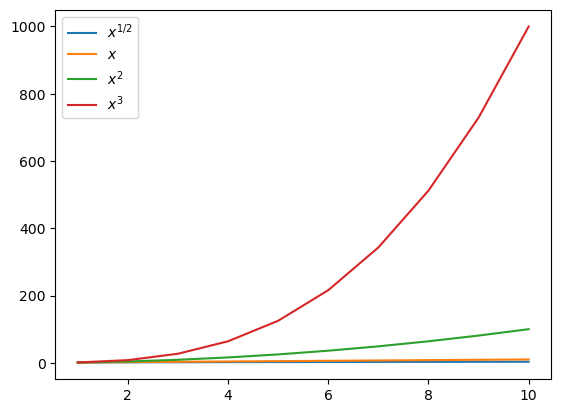

In [2]:
x = np.linspace(1, 10, 10)  # 10 points evenly between 1 and 10.
print(x)
plt.plot(x, x**0.5, label=r"$x^{1/2}$")
plt.plot(x, x**1, label=r"$x$")
plt.plot(x, x**2, label=r"$x^2$")
plt.plot(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

When visualizing functions where $y$ has many different orders of magnitude, a logarithmic scale is useful:

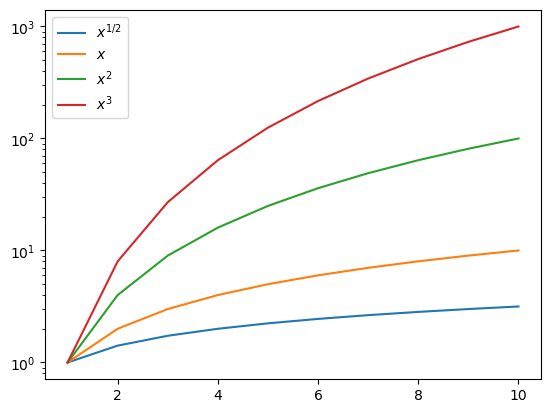

In [3]:
x = np.linspace(1, 10, 10)
plt.semilogy(x, x**0.5, label=r"$x^{1/2}$")
plt.semilogy(x, x**1, label=r"$x$")
plt.semilogy(x, x**2, label=r"$x^2$")
plt.semilogy(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

When also the $x$-axis contains many orders of magnitude, a log-log plot is most useful:

[1.e+01 1.e+02 1.e+03 1.e+04 1.e+05 1.e+06 1.e+07 1.e+08 1.e+09 1.e+10]


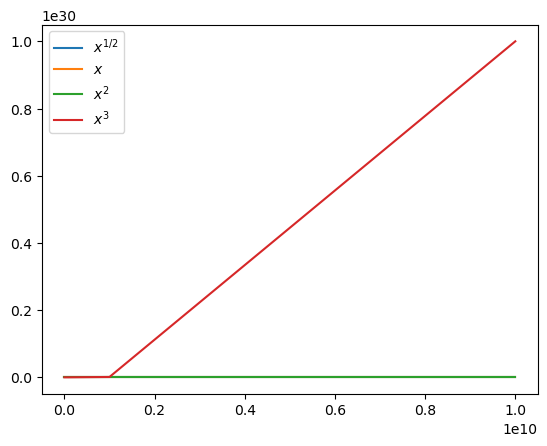

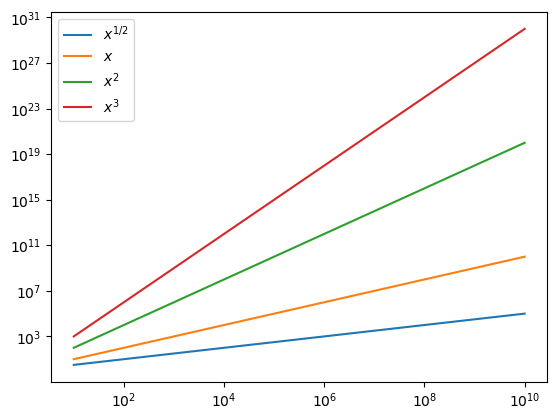

In [4]:
x = np.logspace(1, 10, 10, base=10)  # 10 points evenly between 10^1 and 10^10.
print(x)

plt.plot(x, x**0.5, label=r"$x^{1/2}$")
plt.plot(x, x**1, label=r"$x$")
plt.plot(x, x**2, label=r"$x^2$")
plt.plot(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

plt.loglog(x, x**0.5, label=r"$x^{1/2}$")
plt.loglog(x, x**1, label=r"$x$")
plt.loglog(x, x**2, label=r"$x^2$")
plt.loglog(x, x**3, label=r"$x^3$")
plt.legend()
plt.show()

## Plots of arbitrary curves in the $(x,y)$ plane

So far, in all our plots, $y$ was a function of $x$. But this is not the only possibility. One can draw arbitrary curves in the $(x,y)$ plane. Next are two examples

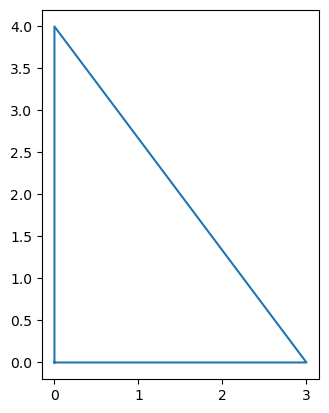

In [5]:
# plot a triangle
x = [0, 3, 0, 0]
y = [0, 0, 4, 0]
plt.plot(x,y)
# set aspect ratio to one
plt.gca().set_aspect('equal')

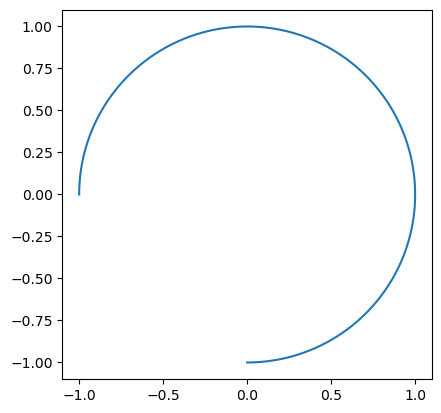

In [6]:
# we plot three quarters of a circle from (0,-1) going counter clockwise to (-1,0)
t = np.linspace(-0.5*np.pi, np.pi, 271)
x = np.cos(t)    
y = np.sin(t)
plt.plot(x,y)
# set the aspectratio to 1 so that it truely looks like a circle
plt.gca().set_aspect('equal')

---

# Exercise 1

Show that the Gram–Schmidt orthogonalization of an $m \times m$ matrix requires approximately $m^3$ multiplications and $m^3$ additions.


***Answer***:

The modified Gram-Schmidt orthogonalization procedure can be represented by the following pseudocode. We keep track of the number of multiplications and additions alongside: 

- **for** $k = 1$ **to** $m$:
    - $r_{kk} = \|a_k\|_2$ &nbsp;&nbsp;&nbsp;&nbsp; *{calculating norm $\rightarrow m$ multiplications; $m-1$ additions}*
    - **if** $r_{kk} = 0$ **then** stop 
    - $q_k = a_k / r_{kk}$ &nbsp;&nbsp;&nbsp;&nbsp; *{$m$ divisions}*
    - **for** $j = k + 1$ **to** $m$:
        - $r_{kj} = q_k^T a_j$ &nbsp;&nbsp;&nbsp;&nbsp; *{$m$ multiplications; $m-1$ additions}*
        - $a_j = a_j - r_{kj} q_k$ &nbsp;&nbsp;&nbsp;&nbsp; *{$m$ multiplications; $m$ subtractions}*
    - **end**
- **end**

**Calculating the number of addition operations**:

We loop from $1$ to $m$ since our matrix undergoing orthogonalization is composed of $m$ vectors. There are $m-1$ additions in the outer for loop and $m-1$ additions in the inner for loop. Total addition operations can be calculated:
$$ \sum^m_{k=1} \left( (m-1) + \sum^m_{j=k+1} (m-1) \right) $$
$$ \rightarrow m(m-1) + \sum^m_{k=1} (m-1)(m-i) $$
$$ \rightarrow m(m-1) + ((m-1)(m-1) + (m-1)(m-2) + \ldots + (m-1)(m-m)) $$
$$ \rightarrow m(m-1) + (m-1)((m-1) + (m-2) + \ldots + (m-m)) $$
$$ \rightarrow m(m-1) + (m-1)(m^2 - (1 + 2 + \ldots + m)) $$
$$ \rightarrow m(m-1) + (m-1)(m^2 - \frac{m(m+1)}{2}) $$
$$ \rightarrow m(m-1) + \frac{m(m-1)(m-1)}{2} $$
$$ \rightarrow \frac{1}{2} m(m+1)(m-1) $$
$$ \thickapprox m^3 $$

There are $m^3$ additions in the given case. 

**Calculating the number of multiplication operations**:

There are $m$ multiplications in the outer for loop and $2m$ multiplication in the inner for loop. Total multiplication operations can be calculated:
$$ \sum^m_{k=1} \left( m + \sum^m_{j=k+1} 2m \right) $$
$$ \rightarrow m^2 + \sum^m_{k=1} 2m(m-i) $$
$$ \rightarrow m^2 + (2m(m-1) + 2m(m-2) + \ldots + 2m(m-m)) $$
$$ \rightarrow m^2 + 2m((m-1) + (m-2) + \ldots + (m-m)) $$
$$ \rightarrow m^2 + 2m(m^2 - (1 + 2 + \ldots + m)) $$
$$ \rightarrow m^2 + 2m(m^2 - \frac{m(m+1)}{2}) $$
$$ \rightarrow m^2 + \frac{2m^2(m-1)}{2} $$
$$ \rightarrow m^3 $$

There are $m^3$ multiplications in the given case. 

-----
# Exercise 2
We want to reconstruct a function $s(t)$ (also called the signal in this exercise), $t \in [0,1]$, from data given by
$$d(t) = \int_0^1 s(t) \, dt + \text{noise}.$$
We assume the data is given at $n$ equally space time points $t_j = j h$, $h = \frac{1}{n}$, $j=1,2, \ldots, n$. The data is therefore a vector $d = [d_1, \ldots, d_n]$, where $d_j$ denotes the value at $t_j$. 
The signal $s$ is to be reconstructed at time points 
$t_{j-1/2} = (j-1/2)h$ for $j = 1,2, \ldots, n$. It is described by a vector $s = [s_1, \ldots, s_n]$ with $s_j$ the value at $t_{j-1/2}$.
Numerical integration is described in Chapter 8 of the book by Heath. Using the composite midpoint rule, the vectors $s$ and $d$ are related by
$$d = A \cdot s + \text{noise}$$
where
$$A = \begin{bmatrix} 
h & 0 & 0 & \ldots & 0 \\
h & h & 0 & \ldots & 0 \\
h & h & h & \ddots &  \vdots \\
\vdots & \vdots & \ddots & \ddots & 0 \\
h & h & \ldots & h  & h 
\end{bmatrix}.$$


## (a)
As a test signal we take
$$s_{\rm true}(t) = \left\{
\begin{array}{ll} 
1 & \text{if $0.05 \le |t-1/2|<0.15$}\\
0.7 & \text{if $|t-1/2|<0.05$}\\
0 & \text{otherwise} \end{array} 
\right. .$$ 
Generate data $d_0$ without noise and data $d_\epsilon$ with noise, where the noise is normally distributed, with mean zero and standard deviation $\epsilon = 0.005$.
Take for example $n=100$. Plot the data.

In [7]:
# Parameters
n = 100                             # Number of points
h = 1 / n                           # Step size
t_points = [j*h for j in range(n)]  # Time points

# For noise
mu = 0                              # Mean
epsilon = 0.005                     # Standard deviation

In [8]:
# Define the piecewise function s_true(t)
def piece_wise(t):
    a = abs(t - 0.5)
    if a < 0.05:
        return 0.7
    elif a < 0.15 and a >= 0.05:
        return 1
    else:
        return 0
    
# Generate the true signal
def true_signal(h, n):
    s_values = [piece_wise((j - 0.5)*h) for j in range(n)]
    s_values = np.array(s_values)
    return s_values

# Construct the matrix A
def construct_matrix(A, h, n):
    for i in range(n):
        for j in range(n):
            if(i >= j):
                A[i][j] = h
    return A

# Generate the signal without noise
def noiseless_signal(h, n):
    A_empty = np.zeros((n, n))
    A = construct_matrix(A_empty, h, n)
    s_true = true_signal(h, n)
    d_0 = A @ s_true
    d_0 = np.array(d_0)
    return d_0

# Generate the noisy signal
def noisy_signal(mu, epsilon, noiseless_signal):
    d_epsilon = []
    d_0 = noiseless_signal
    noise = np.random.normal(mu, epsilon, n)  # Generate noise
    
    for i in range (len(noise)):
        d_epsilon.append(d_0[i] + noise[i])
    
    d_epsilon = np.array(d_epsilon)
    
    return d_epsilon

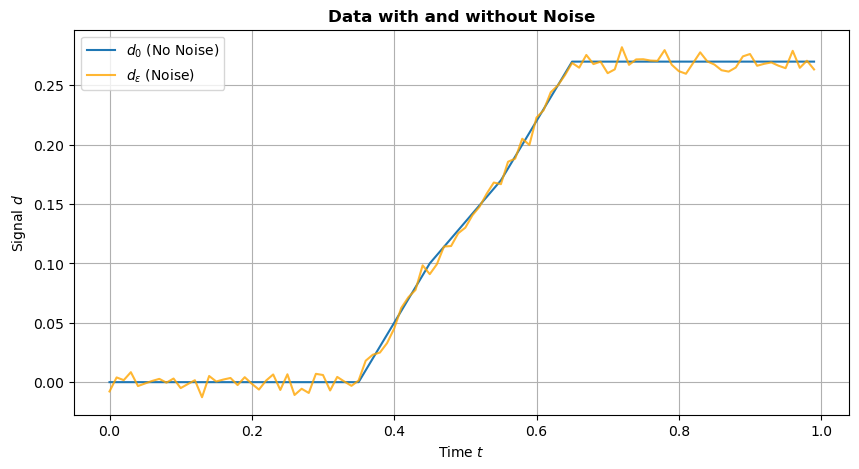

In [9]:
d_0 = noiseless_signal(h, n)
d_epsilon = noisy_signal(mu, epsilon, d_0)

# Plotting d_0 and d_epsilon
plt.figure(figsize=(10, 5))
plt.plot(t_points, d_0, label=r"$d_0$ (No Noise)", linestyle="-")
plt.plot(t_points, d_epsilon, label=r"$d_\epsilon$ (Noise)", 
         linestyle="-", color="orange", alpha=0.8)
plt.xlabel("Time $t$")
plt.ylabel("Signal $d$")
plt.title("Data with and without Noise", fontweight="bold")
plt.grid()
plt.legend()
plt.show()

## (b)
Try to determine $s$ from $d_0$ by inverting the matrix $A$, ignoring the noise term.
Do the same with $d_\epsilon$ instead of $d_0$. Plot the results. What do you observe about the errors in the inversion?

You may use a library routine for matrix inversion/solving a linear system.

***Answer***:

When we reconstruct the signal $s$ by inverting the matrix $A$ with both noiseless data $d_0$ and noisy data $d_\epsilon$, we observe distinct behaviors in the inversion errors. 

The reconstruction using $d_\epsilon$ is significantly impacted by noise. Small perturbations in $d_\epsilon$ are amplified during inversion, leading to dips and fluctuations in the plot of the reconstructed signal. This effect is especially pronounced in regions where the true signal has abrupt changes, as these areas are more sensitive to noise.

In comparison, using the noiseless data $d_0$ provides a reconstruction that is much closer (almost exactly equal) to the true signal $s_{\text{true}}$, as there is no noise to be amplified. This implies that while the inversion process can recover the true signal accurately in the absence of noise, its accuracy decreases significantly when some amount of noise is present, regardless of its magnitude.

In [10]:
from numpy.linalg import inv

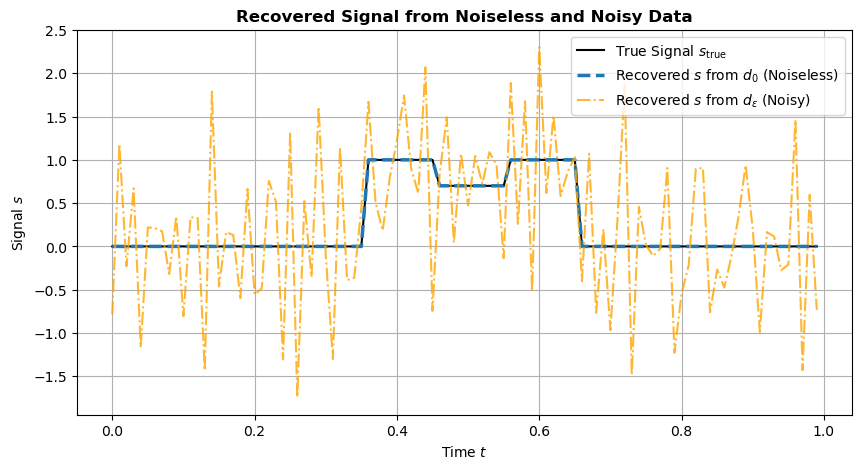

In [11]:
# Construct the matrix A
A_empty = np.zeros((n, n))
A = construct_matrix(A_empty, h, n)

# Solve for s using the noiseless data d_0
s_0 = inv(A) @ d_0   

# Solve for s using the noisy data d_epsilon
s_epsilon = inv(A) @ d_epsilon 

# Generate the true signal
s_values = true_signal(h, n)

# Plotting the true signal and the reconstructed signals
plt.figure(figsize=(10, 5))
plt.plot(t_points, s_values, label=r"True Signal $s_{\rm true}$", 
         color="black", linestyle="-")
plt.plot(t_points, s_0, label=r"Recovered $s$ from $d_0$ (Noiseless)", 
         linestyle="--", linewidth=2.5)
plt.plot(t_points, s_epsilon, label=r"Recovered $s$ from $d_\epsilon$ (Noisy)", 
         linestyle="-.", color="orange", alpha=0.8)
plt.xlabel("Time $t$")
plt.ylabel("Signal $s$")
plt.title("Recovered Signal from Noiseless and Noisy Data", 
          fontweight="bold")
plt.legend()
plt.grid()

## (c)
One way to address the issue just observed is by truncated SVD regularization. Suppose $A = U \Sigma V^T$ is the singular value decomposition of $A$. 

Express the inverse $A^{-1}$ in terms of $U, V$ and $\Sigma$, or in terms of $U$, $V$ and the singular values.

Let $k$ be some integer less or equal than $n$. Denote by $B_k$ the matrix that is obtained from $A$ by setting the smallest $n-k$ singular values to zero (and keeping $U$, $V$ and the first $k$ singular values the same). 

In truncated SVD regularization, an estimate for $s$ is obtained by applying the pseudoinverse $B_k^{+}$ to the data (instead of the true inverse $A^{-1}$) (see section 3.6 of Heath). Try truncated SVD regularization for various values of $k$. Show that for certain values of $k$ the result obtained by truncated SVD regularization is a "better" approximation of the true signal than the result obtained by the true inverse $A^{-1}$.

Note that better can mean different things, it can mean "visually better" or "quantitatively better" in some norm to be specified, try to be precise in what you write down.

What happens if you choose $k$ too small?

You may use library routines to compute the SVD.

***Answer***:

We first visually analyze the plot generated to determine appropriate values of $k$. If $k$ is too small, many singular values will be discarded, resulting in a loss of important information and potentially leading to underfitting. However, if $k$ is too large, too many singular values &mdash; including those associated with noise &mdash; will be retained, which may cause the model to overfit by capturing more noise than the true signal. Moderate values of $k$ provide the best estimation of the true signal (somewhere between 10 and 30, based on our plot).

Thinking about it quantitatively, we can measure the Mean Squared Error (MSE) between the approximated signal (result of truncated SVD) and the true signal. It would be calculated as: 
$$ MSE(k) = \frac{1}{n} \sum^n_{i=1} (s_{true, i} - s_{k,i})^2 $$
Lower MSE indicates that the approximated signal is closer to the true signal on average.

MSE becomes high when $k$ is too low or too high, but it is minimized when $k$ takes on moderate values.


In [12]:
from numpy.linalg import svd

In [13]:
U, Sigma, Vt = svd(A)   # Perform SVD on matrix A
V = Vt.T                # Transpose to get V

# Reconstruct the signal using truncated SVD
def truncated(U, Sigma, V, k):
    diagonal_elements = []      # Diagonal elements of Sigma_trunc
    for i, s in enumerate(Sigma):
        if i < k:
            diagonal_elements.append(1 / s) # Inverse of singular values
        else:
            diagonal_elements.append(0)     # Zero out the rest
    
    Sigma_trunc_inv = np.diag(diagonal_elements) 
    trunc = V @ Sigma_trunc_inv @ U.T 
    return trunc


In [14]:
k_values = [1, 5, 10, 20, 30, 50] # Different values of k

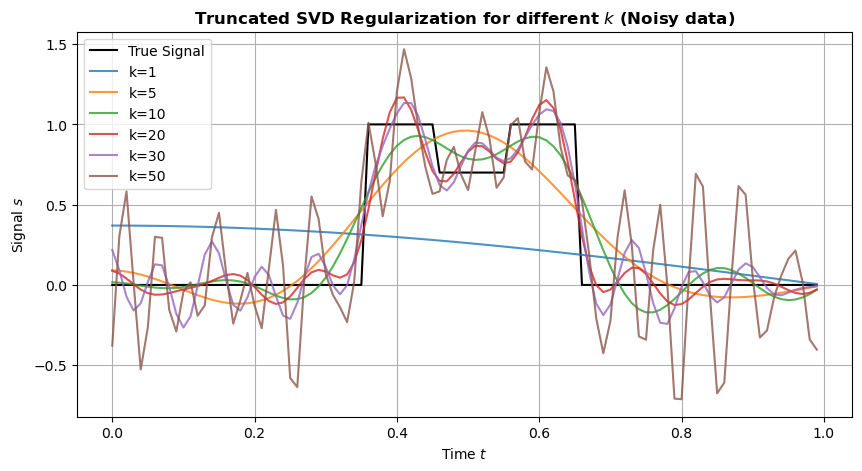

In [15]:
# Plotting the true signal and the truncated SVD reconstructions for each k in one plot
plt.figure(figsize=(10, 5))
plt.plot(t_points, s_values, label="True Signal", color="black", linestyle="-")

# Loop over k values to plot the reconstruction for each
for k in k_values:
    A_trunc_inv = truncated(U, Sigma, V, k)
    s_approx_noisy = A_trunc_inv @ d_epsilon  # Using noisy data
    plt.plot(t_points, s_approx_noisy, label=f"k={k}", linestyle="-", 
             alpha=0.8)

# Adding labels and title
plt.xlabel("Time $t$")
plt.ylabel("Signal $s$")
plt.title("Truncated SVD Regularization for different $k$ (Noisy data)", 
          fontweight="bold")
plt.legend()
plt.grid()
plt.show()

## (d)

Make a plot of the singular values of $A$. Explain your findings in (b) and (c). Part of your explanation should refer to the plot.

***Answer***:

The singular values of matrix $A$ decay rapidly, with many approaching zero. These small singular values are associated with directions that contribute little to the overall signal but are highly sensitive to noise. When inverting $ A $ directly (using all singular values), these small values amplify noise, resulting in an oscillatory and unstable reconstruction that overfits the noisy data. This explains why the full inverse $A^{-1}$ often produces a poor approximation of the true signal.

Truncated SVD regularization mitigates this issue by discarding the smallest singular values and retaining only the largest ones, which capture the stable components of the signal. By choosing a moderate $k$, such as $k = 10$ or $ k = 20$, we obtain a balance that captures essential signal features while filtering out noise-sensitive components. This leads to a smoother and more accurate approximation of the true signal, demonstrating that truncated SVD with an optimal $k$ provides a "better" reconstruction than the full inverse.

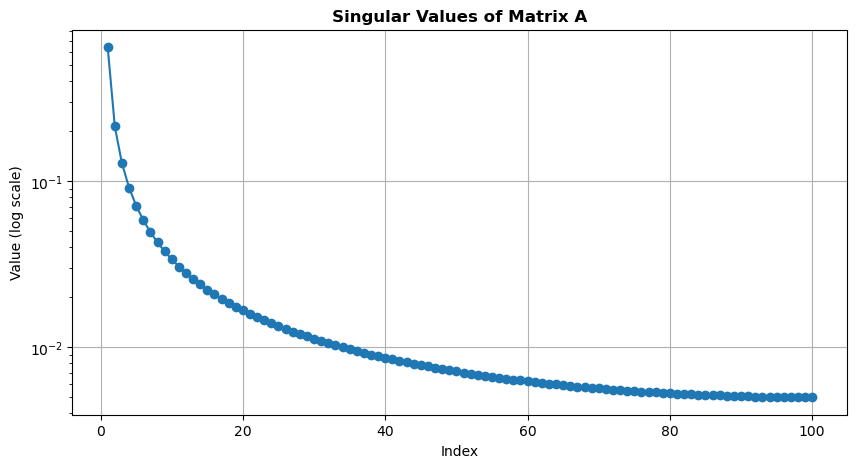

In [16]:
plt.figure(figsize=(10, 5))
plt.semilogy(range(1, len(Sigma) + 1), Sigma, marker="o", linestyle="-")
plt.xlabel("Index")
plt.ylabel("Value (log scale)")
plt.title("Singular Values of Matrix A", fontweight="bold")
plt.grid()
plt.show()